# lab1
#### Выполнил: Тропин Михаил М8О-311Б-23 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Структура датасета
В датасете представлены следующие столбцы:

- ApplicationDate: Дата подачи заявки на кредит
- Age: Возраст заявителя
- AnnualIncome: Годовой доход
- CreditScore: Оценка кредитоспособности
- LoanAmount: Запрашиваемая сумма кредита
- LoanDuration: Срок погашения кредита
- MaritalStatus: Семейное положение заявителя
- NumberOfDependents: Количество иждивенцев
- HomeOwnershipStatus: Статус владения жильем
- MonthlyDebtPayments: Ежемесячные обязательства по долгам
- CreditCardUtilizationRate: Процент использования кредитной карты
- NumberOfOpenCreditLines: Активные кредитные линии
- NumberOfCreditInquiries: Количество запросов на кредит
- DebtToIncomeRatio: Соотношение долга к доходу
- BankruptcyHistory: История банкротств
- LoanPurpose: Цель кредита
- PreviousLoanDefaults: Предыдущие дефолты по кредитам
- PaymentHistory: История платежей
- LengthOfCreditHistory: Длительность кредитной истории
- SavingsAccountBalance: Баланс сберегательного счета
- CheckingAccountBalance: Баланс расчетного счета
- TotalAssets: Общая стоимость активов
- TotalLiabilities: Общая сумма обязательств
- MonthlyIncome: Ежемесячный доход
- UtilityBillsPaymentHistory: История платежей по коммунальным услугам
- JobTenure: Длительность работы на текущем месте
- EmploymentStatus: Статус занятости
- EducationLevel: Уровень образования
- Experience: Опыт работы
- NetWorth: Чистая стоимость активов
- BaseInterestRate: Базовая процентная ставка
- InterestRate: Применяемая процентная ставка
- MonthlyLoanPayment: Ежемесячный платеж по кредиту
- TotalDebtToIncomeRatio: Общее соотношение долга к доходу
- RiskScore: Оценка риска

▎ Файлы
- train.csv - обучающая выборка
- test.csv - тестовая выборка
- ex.csv - пример файла для отправки в тестирующую систему

In [2]:
try:
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')
except FileNotFoundError:
    print("Ошибка: Файлы 'train.csv' или 'test.csv' не найдены.")
    
print('df info')
print(train_df.info())
print('test_df info')
print(test_df.info())
print('nulls cnt')
print(test_df.isna().sum().sum())
print('train_df example')
print(train_df.head())
print('RiskScore example')
print(train_df["RiskScore"])

df info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11017 entries, 0 to 11016
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             10487 non-null  object 
 1   Age                         10487 non-null  float64
 2   AnnualIncome                10487 non-null  float64
 3   CreditScore                 9986 non-null   float64
 4   LoanAmount                  9986 non-null   float64
 5   LoanDuration                10487 non-null  float64
 6   MaritalStatus               10487 non-null  object 
 7   NumberOfDependents          10487 non-null  float64
 8   HomeOwnershipStatus         10487 non-null  object 
 9   MonthlyDebtPayments         9986 non-null   float64
 10  CreditCardUtilizationRate   10487 non-null  float64
 11  NumberOfOpenCreditLines     10487 non-null  float64
 12  NumberOfCreditInquiries     10487 non-null  float64
 13  DebtToIncomeRatio      

In [3]:
print(train_df.describe())
print(test_df.describe())

                Age   AnnualIncome  CreditScore     LoanAmount  LoanDuration  \
count  10487.000000   10487.000000  9986.000000    9986.000000  10487.000000   
mean      39.850386  131587.872127   678.082716   29874.218306     53.439878   
std       11.614132  115791.941909   175.192486   27705.509722     24.493562   
min       18.000000   15000.000000   300.000000    1063.000000     12.000000   
25%       32.000000   20959.500000   550.000000   12658.000000     36.000000   
50%       40.000000   89015.000000   722.500000   21828.500000     48.000000   
75%       48.000000  257025.000000   850.000000   37158.000000     60.000000   
max       80.000000  748508.000000   850.000000  418997.000000    120.000000   

       NumberOfDependents  MonthlyDebtPayments  CreditCardUtilizationRate  \
count        10487.000000          9986.000000               10487.000000   
mean             1.568323           546.458642                   0.284397   
std              1.418684           501.981888  

In [4]:
test_ids = test_df.get('ID', pd.Series(range(len(test_df)), name='ID'))

train_df.dropna(subset=['RiskScore'], inplace=True)

y = train_df['RiskScore']
columns_to_drop = ['RiskScore', 'ID', 'ApplicationDate']

existing_cols_train = [col for col in columns_to_drop if col in train_df.columns]
X = train_df.drop(columns=existing_cols_train)

columns_to_drop_test = ['ID', 'ApplicationDate']
existing_cols_test = [col for col in columns_to_drop_test if col in test_df.columns]
X_test = test_df.drop(columns=existing_cols_test)

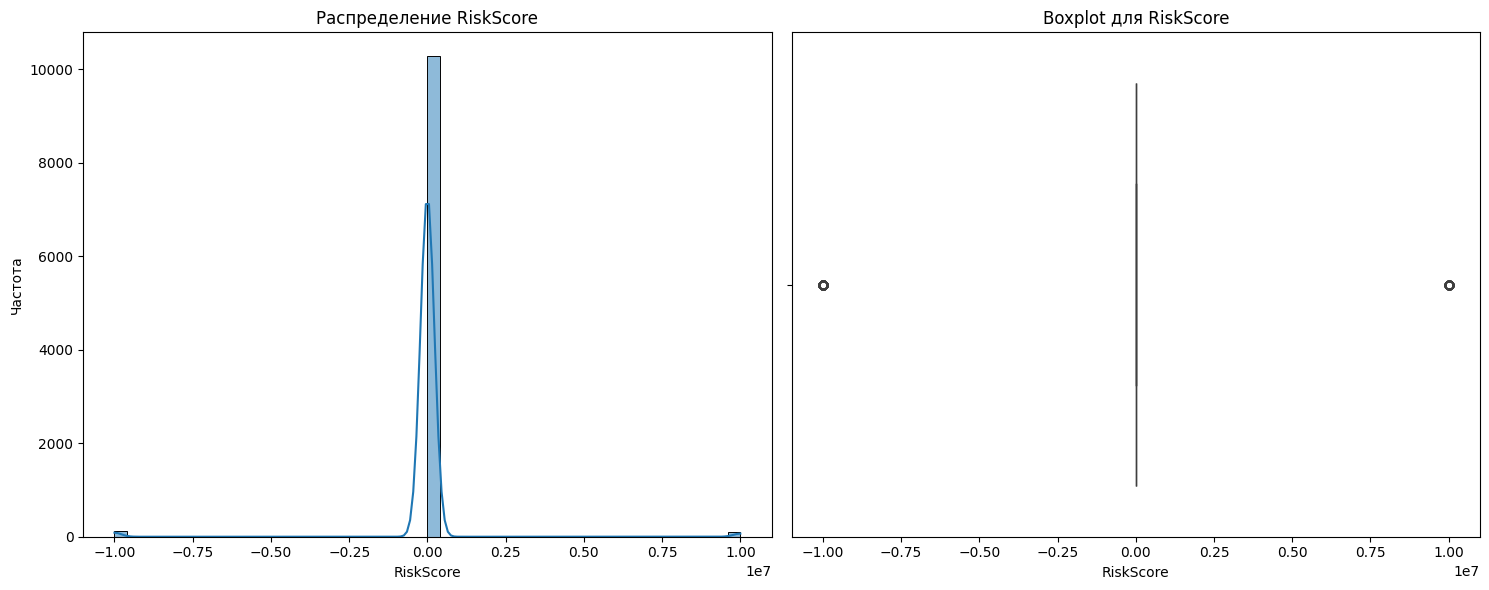

1% квантиль: -9999999.0 99% квантиль: 90.22039604434617


In [5]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.histplot(y, kde=True, bins=50)
plt.title('Распределение RiskScore')
plt.xlabel('RiskScore')
plt.ylabel('Частота')

plt.subplot(1, 2, 2)
sns.boxplot(x=y)
plt.title('Boxplot для RiskScore')
plt.xlabel('RiskScore')

plt.tight_layout()
plt.show()

q_low, q_high = y.quantile([0.01, 0.99])
print("1% квантиль:", q_low, "99% квантиль:", q_high)

Числовые признаки: 28
Категориальные (число): 5

Категориальные признаки: ['MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose', 'EmploymentStatus', 'EducationLevel']


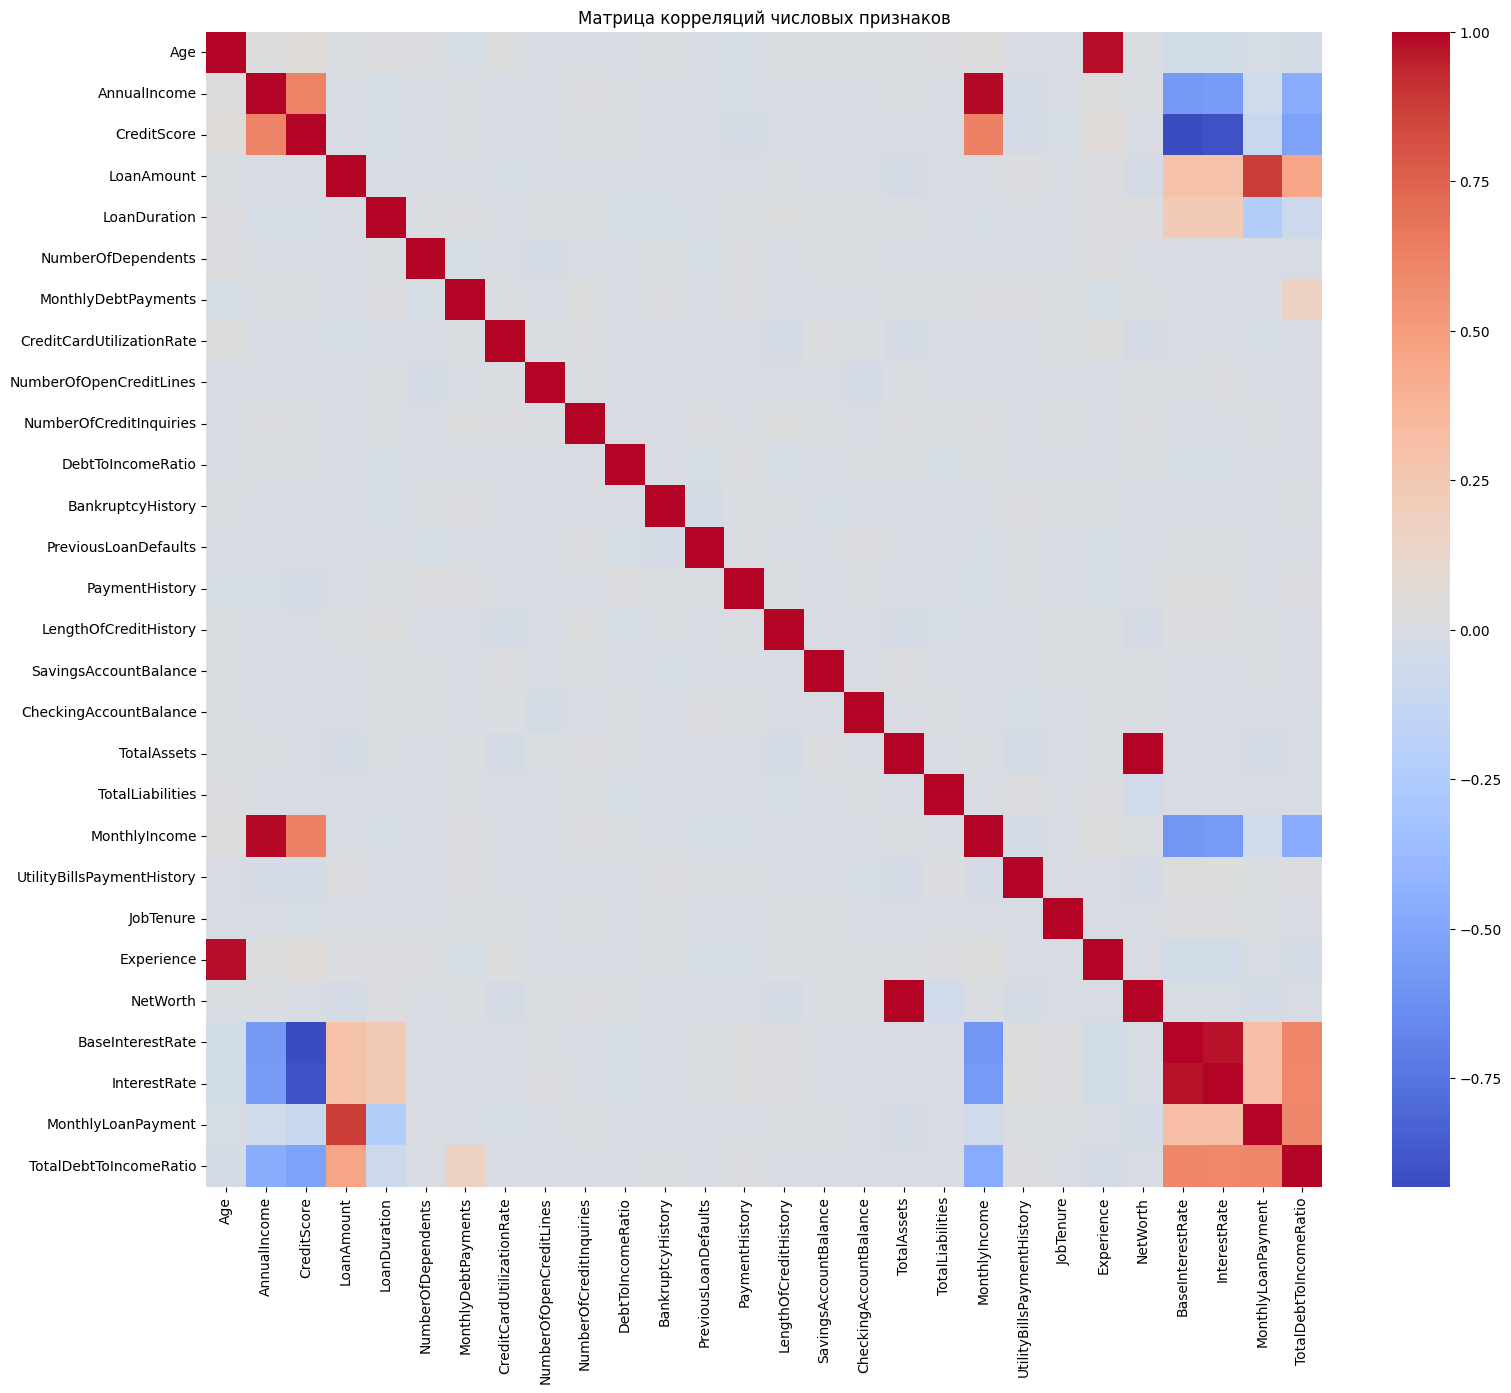

In [6]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print(f"Числовые признаки: {len(numeric_features)}")
print(f"Категориальные (число): {len(categorical_features)}")
print("\nКатегориальные признаки:", categorical_features)

plt.figure(figsize=(18, 15))
corr_mat = X[numeric_features].corr()
sns.heatmap(corr_mat, cmap='coolwarm', annot=False)
plt.title('Матрица корреляций числовых признаков')
plt.show()

15 коррелянтов:
Age                         NaN
AnnualIncome                NaN
CreditScore                 NaN
LoanAmount                  NaN
LoanDuration                NaN
NumberOfDependents          NaN
MonthlyDebtPayments         NaN
CreditCardUtilizationRate   NaN
NumberOfOpenCreditLines     NaN
NumberOfCreditInquiries     NaN
DebtToIncomeRatio           NaN
BankruptcyHistory           NaN
PreviousLoanDefaults        NaN
PaymentHistory              NaN
LengthOfCreditHistory       NaN
Name: RiskScore, dtype: float64

15 некорелянтов:
PaymentHistory               NaN
LengthOfCreditHistory        NaN
SavingsAccountBalance        NaN
CheckingAccountBalance       NaN
TotalAssets                  NaN
TotalLiabilities             NaN
MonthlyIncome                NaN
UtilityBillsPaymentHistory   NaN
JobTenure                    NaN
Experience                   NaN
NetWorth                     NaN
BaseInterestRate             NaN
InterestRate                 NaN
MonthlyLoanPayment       

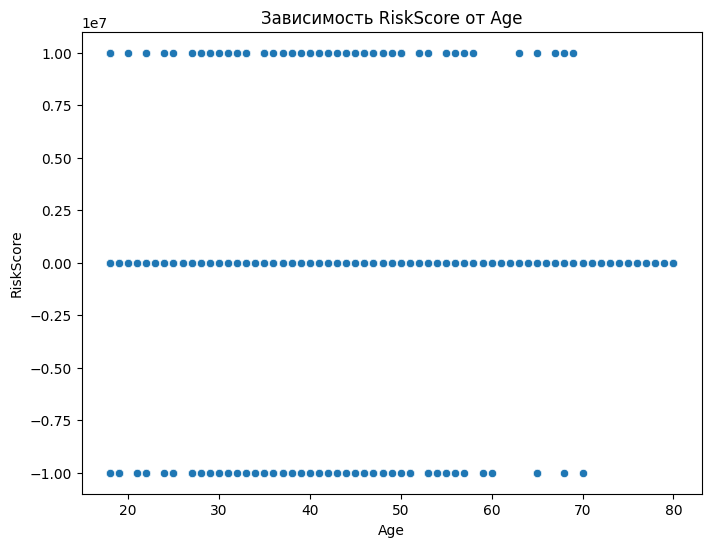

In [7]:
corr_with_score = corr_mat.join(y.to_frame())['RiskScore'].sort_values(ascending=False)

print("15 коррелянтов:")
print(corr_with_score.head(15))

print("\n15 некорелянтов:")
print(corr_with_score.tail(15))

most_correlated_feature = corr_with_score.index[0]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[most_correlated_feature], y=y)
plt.title(f'Зависимость RiskScore от {most_correlated_feature}')
plt.xlabel(most_correlated_feature)
plt.ylabel('RiskScore')
plt.show()

In [8]:
print(f'Пропуски в df: {train_df.isna().sum().sum()}')
print(f'Пропуски в df_test: {test_df.isna().sum().sum()}')

Пропуски в df: 4509
Пропуски в df_test: 0


In [9]:
for col in numeric_features:
    median_val = X[col].median()
    X[col] = X[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

for col in categorical_features:
    # mode_val = X[col].mode()[0]
    mode_values = X[col].mode()
    print(len(mode_values))
    middle_index = len(mode_values) // 2
    print(middle_index)
    mode_val = mode_values.iloc[middle_index] if len(mode_values) > 0 else "Other"
    print(mode_val)
    X[col] = X[col].fillna(mode_val)
    X_test[col] = X_test[col].fillna(mode_val)


1
0
Married
1
0
Mortgage
1
0
Home
1
0
Employed
1
0
High School


In [10]:
print(f'Пропуски в df: {X.isna().sum().sum()}')
print(f'Пропуски в df_test: {X_test.isna().sum().sum()}')

Пропуски в df: 0
Пропуски в df_test: 0


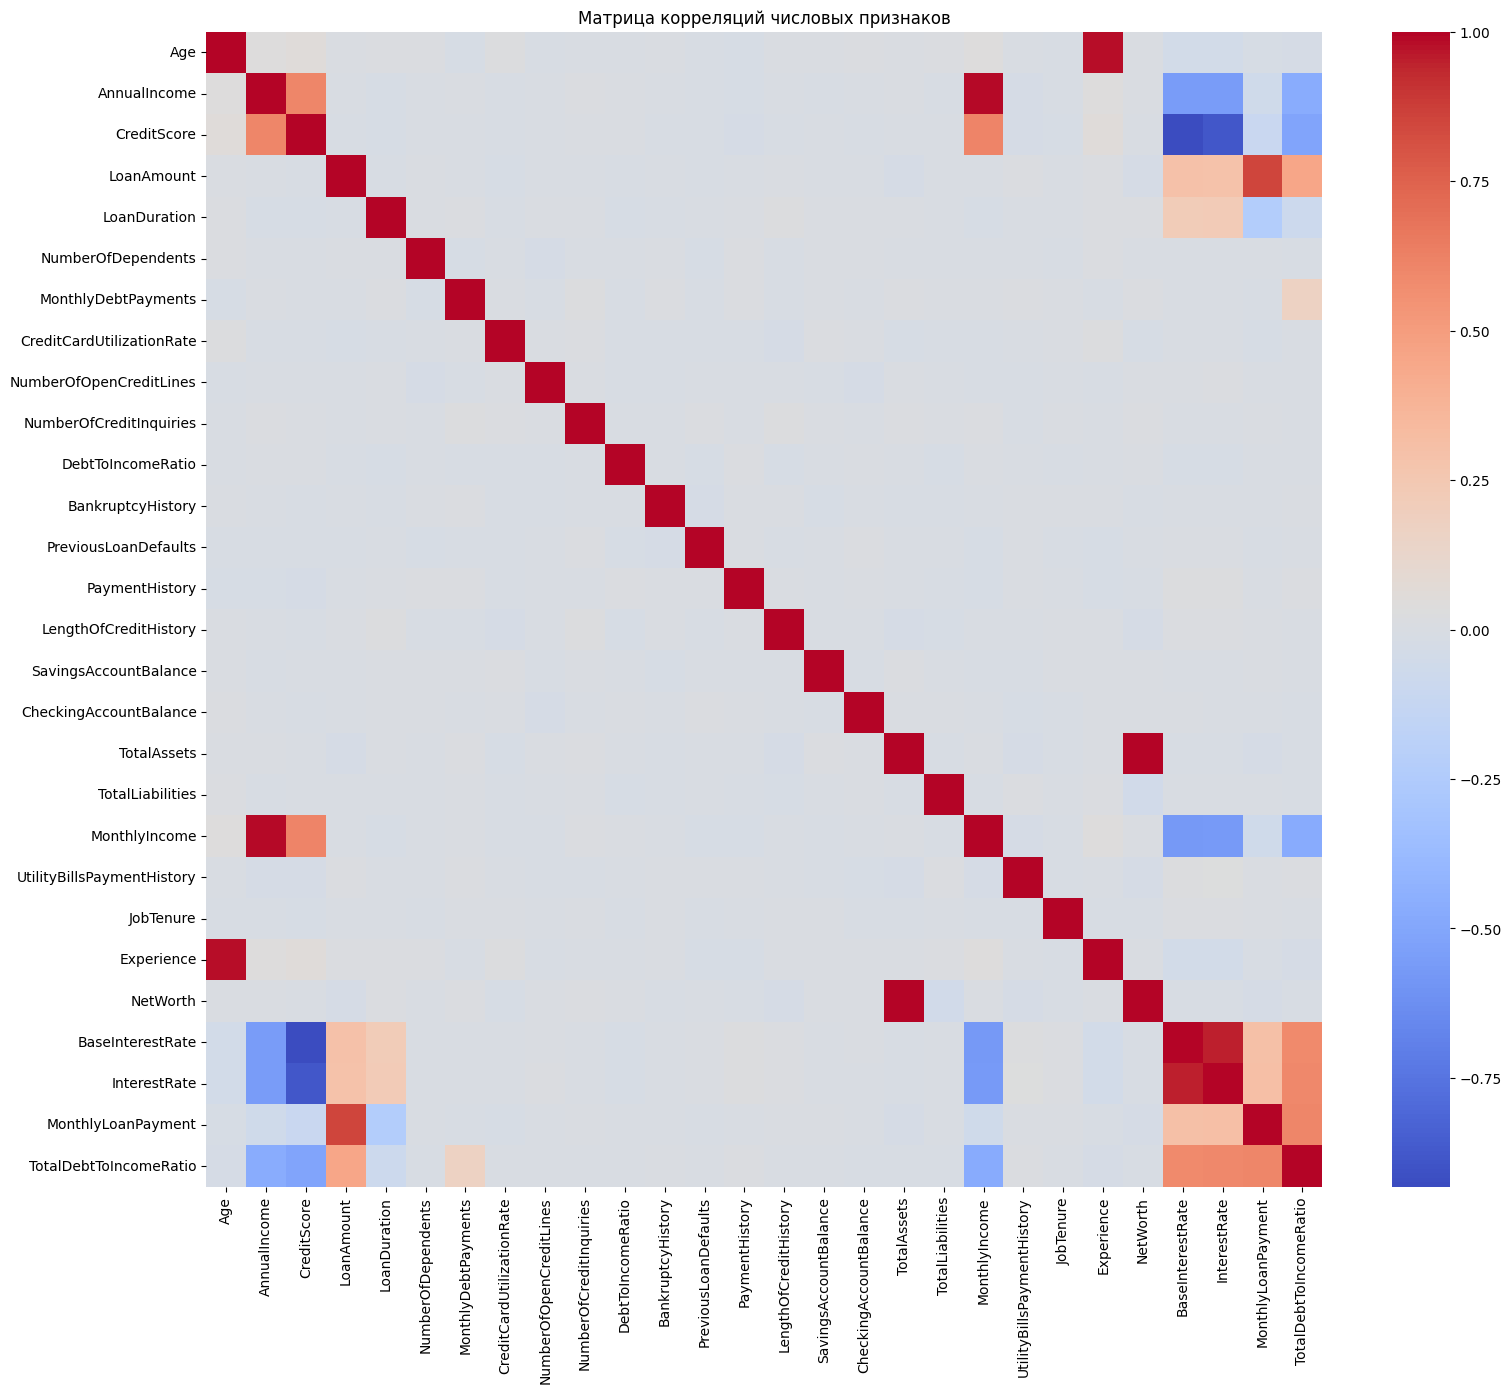

Топ-10 признаков, наиболее коррелирующих с RiskScore:
NumberOfDependents            0.023314
PaymentHistory                0.019144
TotalDebtToIncomeRatio        0.013879
UtilityBillsPaymentHistory    0.013865
MonthlyLoanPayment            0.012366
NumberOfCreditInquiries       0.011055
LoanAmount                    0.010255
LengthOfCreditHistory         0.009448
AnnualIncome                  0.008460
SavingsAccountBalance         0.007611
Name: RiskScore, dtype: float64

Топ-10 признаков, наименее коррелирующих с RiskScore:
Age                        0.004648
BankruptcyHistory          0.004131
JobTenure                  0.003822
InterestRate               0.003388
CreditScore                0.003203
MonthlyDebtPayments        0.002862
LoanDuration               0.001880
CheckingAccountBalance     0.001646
BaseInterestRate           0.001298
NumberOfOpenCreditLines    0.000730
Name: RiskScore, dtype: float64


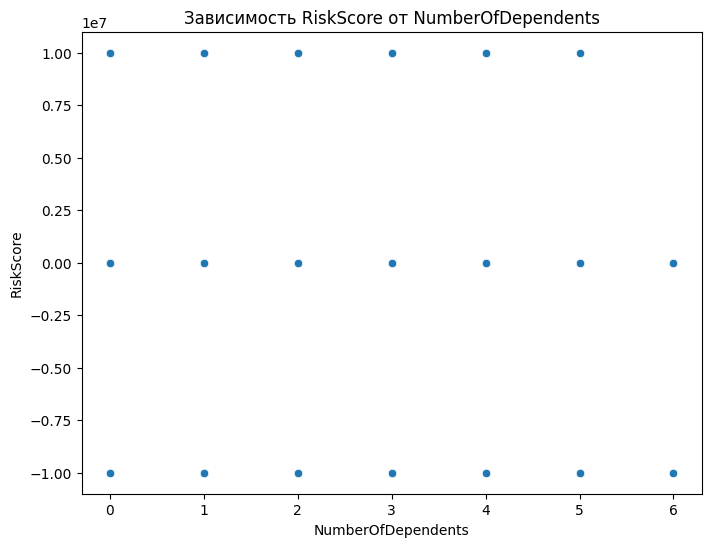

In [11]:
plt.figure(figsize=(18, 15))
correlation_matrix = X[numeric_features].corr()
sns.heatmap(correlation_matrix, cmap='coolwarm')
plt.title('Матрица корреляций числовых признаков')
plt.show()

temp_df_numeric = X[numeric_features].join(y)

correlation_with_target = temp_df_numeric.corr()['RiskScore'].abs().sort_values(ascending=False)

print("Топ-10 признаков, наиболее коррелирующих с RiskScore:")
print(correlation_with_target.head(11).drop('RiskScore'))

print("\nТоп-10 признаков, наименее коррелирующих с RiskScore:")
print(correlation_with_target.tail(10))

most_correlated_feature = correlation_with_target.index[1]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[most_correlated_feature], y=y)
plt.title(f'Зависимость RiskScore от {most_correlated_feature}')
plt.xlabel(most_correlated_feature)
plt.ylabel('RiskScore')
plt.show()

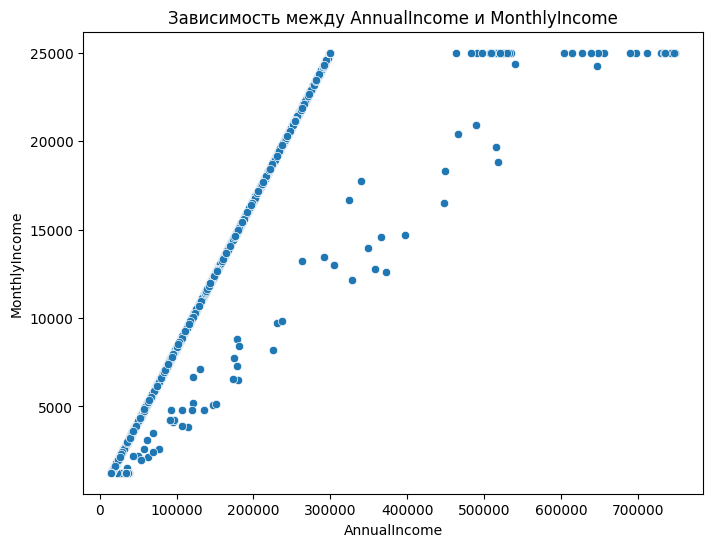

In [12]:

feature1 = 'AnnualIncome'
feature2 = 'MonthlyIncome'

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[feature1], y=X[feature2])
plt.title(f'Зависимость между {feature1} и {feature2}')
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.show()

In [13]:
# Удаление AnnualIncome
X_processed = train_df.copy()
X_test_processed = test_df.copy()
if 'AnnualIncome' in X_processed.columns:
    X_processed.drop(columns=['AnnualIncome'], inplace=True)
    X_test_processed.drop(columns=['AnnualIncome'], inplace=True)
    print("Столбец 'AnnualIncome' удален.")
y_raw = train_df['RiskScore']
X = X_processed.drop(columns=['RiskScore', 'ID', 'ApplicationDate'], errors='ignore')
X_test = X_test_processed.drop(columns=['ID', 'ApplicationDate'], errors='ignore')

Столбец 'AnnualIncome' удален.


In [14]:
# Очистка выбросов в y
Q1 = y_raw.quantile(0.25)
Q3 = y_raw.quantile(0.75)
IQR = Q3 - Q1
k = 1.5
lower_bound = Q1 - k * IQR
upper_bound = Q3 + k * IQR
mask = (y_raw >= lower_bound) & (y_raw <= upper_bound)
y = y_raw[mask]
X = X[X.index.isin(y.index)]

In [15]:
# Заполнение пропусков
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
for col in numeric_features:
    median_val = X[col].median()
    X[col].fillna(median_val, inplace=True)
    X_test[col].fillna(median_val, inplace=True)
for col in categorical_features:
    mode_val = X[col].mode()[0]
    X[col].fillna(mode_val, inplace=True)
    X_test[col].fillna(mode_val, inplace=True)

/tmp/ipykernel_210519/323244199.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(median_val, inplace=True)
/tmp/ipykernel_210519/323244199.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

In [16]:
# Обработка выбросов в признаках
for col in numeric_features:
    lower_percentile = X[col].quantile(0.05)
    upper_percentile = X[col].quantile(0.95)
    X[col] = np.clip(X[col], lower_percentile, upper_percentile)
    X_test[col] = np.clip(X_test[col], lower_percentile, upper_percentile)


In [17]:
# Некие смешные признаки
def create_ratios(df):
    epsilon = 1e-6
    if 'TotalLiabilities' in df.columns and 'TotalAssets' in df.columns:
        df['DebtToAssets_Ratio'] = df['TotalLiabilities'] / (df['TotalAssets'] + epsilon)
    if 'LoanAmount' in df.columns and 'MonthlyIncome' in df.columns:
        df['LoanToIncome_Ratio'] = df['LoanAmount'] / (df['MonthlyIncome'] + epsilon)
    if 'MonthlyLoanPayment' in df.columns and 'MonthlyIncome' in df.columns:
        df['PaymentToIncome_Ratio'] = df['MonthlyLoanPayment'] / (df['MonthlyIncome'] + epsilon)
    return df
X = create_ratios(X)
X_test = create_ratios(X_test)

In [ ]:
# кодируем категориальные признаки как чиселки

# EducationLevel
edu_map = {'Doctorate': 0, 'Master': 1, 'Bachelor': 2, 'Associate': 3, 'High School': 4}
if 'EducationLevel' in X.columns:
    X["EducationLevel_num"] = X["EducationLevel"].map(edu_map).fillna(2)
    X_test["EducationLevel_num"] = X_test["EducationLevel"].map(edu_map).fillna(2)

# EmploymentStatus
employment_map = {"Employed": 0, "Self-Employed": 1, "Unemployed": 2}
if 'EmploymentStatus' in X.columns:
    X["EmploymentStatus_num"] = X["EmploymentStatus"].map(employment_map).fillna(1)
    X_test["EmploymentStatus_num"] = X_test["EmploymentStatus"].map(employment_map).fillna(1)

# MaritalStatus
marital_map = {'Married': 0, 'Single': 1, 'Divorced': 2, 'Widowed': 3}
if 'MaritalStatus' in X.columns:
    X["MaritalStatus_num"] = X["MaritalStatus"].map(marital_map).fillna(1.5)
    X_test["MaritalStatus_num"] = X_test["MaritalStatus"].map(marital_map).fillna(1.5)

# LoanPurpose
loan_map = {'Home': 0, 'Auto': 1, 'Education': 2, 'Debt Consolidation': 3, 'Other': 4}
if 'LoanPurpose' in X.columns:
    X['LoanPurpose_num'] = X['LoanPurpose'].map(loan_map).fillna(2)
    X_test['LoanPurpose_num'] = X_test['LoanPurpose'].map(loan_map).fillna(2)

# HomeOwnershipStatus
home_map = {"Own": 0, "Mortgage": 1, "Rent": 2, "Other": 3}
if 'HomeOwnershipStatus' in X.columns:
    X["HomeOwnershipStatus_num"] = X["HomeOwnershipStatus"].map(home_map).fillna(1.5)
    X_test["HomeOwnershipStatus_num"] = X_test["HomeOwnershipStatus"].map(home_map).fillna(1.5)

In [19]:

from sklearn.preprocessing import PolynomialFeatures


# Бинарные признаки для частых значений MonthlyIncome
if 'MonthlyIncome' in X.columns:
    X['MonthlyIncome_Is1250'] = (X['MonthlyIncome'] == 1250).astype(int)
    X['MonthlyIncome_Is25000'] = (X['MonthlyIncome'] == 25000).astype(int)
    X_test['MonthlyIncome_Is1250'] = (X_test['MonthlyIncome'] == 1250).astype(int)
    X_test['MonthlyIncome_Is25000'] = (X_test['MonthlyIncome'] == 25000).astype(int)


# Бинарные признаки и трансформации CreditScore
if 'CreditScore' in X.columns:
    X['CreditScore_Is850'] = (X['CreditScore'] == 850).astype(int)
    X['CreditScore_Is300'] = (X['CreditScore'] == 300).astype(int)
    X_test['CreditScore_Is850'] = (X_test['CreditScore'] == 850).astype(int)
    X_test['CreditScore_Is300'] = (X_test['CreditScore'] == 300).astype(int)
    
    if 'CreditScore_Log' not in X.columns:
        X['CreditScore_Log'] = np.log1p(X['CreditScore'])
        X_test['CreditScore_Log'] = np.log1p(X_test['CreditScore'])
    if 'CreditScore_Sqrt' not in X.columns:
        X['CreditScore_Sqrt'] = np.sqrt(X['CreditScore'])
        X_test['CreditScore_Sqrt'] = np.sqrt(X_test['CreditScore'])
    if 'CreditScore_Cbrt' not in X.columns:
        X['CreditScore_Cbrt'] = np.cbrt(X['CreditScore'])
        X_test['CreditScore_Cbrt'] = np.cbrt(X_test['CreditScore'])


# Степенные признаки CreditScore
if 'CreditScore' in X.columns:
    if 'CreditScore_sq2' not in X.columns:
        X['CreditScore_sq2'] = X['CreditScore'] ** 2
        X_test['CreditScore_sq2'] = X_test['CreditScore'] ** 2
    if 'CreditScore_sq3' not in X.columns:
        X['CreditScore_sq3'] = X['CreditScore'] ** 3
        X_test['CreditScore_sq3'] = X_test['CreditScore'] ** 3


# Трансформации TotalDebtToIncomeRatio
if 'TotalDebtToIncomeRatio' in X.columns:
    if 'TotalDebtToIncomeRatio_sqrt3' not in X.columns:
        X["TotalDebtToIncomeRatio_sqrt3"] = np.cbrt(X['TotalDebtToIncomeRatio'])
        X_test['TotalDebtToIncomeRatio_sqrt3'] = np.cbrt(X_test['TotalDebtToIncomeRatio'])
    if 'TotalDebtToIncomeRatio_sqrt2' not in X.columns:
        X["TotalDebtToIncomeRatio_sqrt2"] = np.sqrt(X['TotalDebtToIncomeRatio'])
        X_test['TotalDebtToIncomeRatio_sqrt2'] = np.sqrt(X_test['TotalDebtToIncomeRatio'])
    if 'TotalDebtToIncomeRatio_log' not in X.columns:
        X["TotalDebtToIncomeRatio_log"] = np.log1p(X['TotalDebtToIncomeRatio'])
        X_test['TotalDebtToIncomeRatio_log'] = np.log1p(X_test['TotalDebtToIncomeRatio'])


# Взаимодействие CreditScore и TotalDebtToIncomeRatio
if 'CreditScore' in X.columns and 'TotalDebtToIncomeRatio' in X.columns:
    if 'CreditScore_TotalDebtToIncomeRatio' not in X.columns:
        X["CreditScore_TotalDebtToIncomeRatio"] = X["CreditScore"] * X["TotalDebtToIncomeRatio"]
        X_test["CreditScore_TotalDebtToIncomeRatio"] = X_test["CreditScore"] * X_test["TotalDebtToIncomeRatio"]
    
    if 'Log_CreditScore_TotalDebtToIncomeRatio' not in X.columns:
        X["Log_CreditScore_TotalDebtToIncomeRatio"] = np.log1p(X["CreditScore"]) * X["TotalDebtToIncomeRatio"]
        X_test["Log_CreditScore_TotalDebtToIncomeRatio"] = np.log1p(X_test["CreditScore"]) * X_test["TotalDebtToIncomeRatio"]


# Взаимодействие MonthlyIncome и LoanAmount
if 'MonthlyIncome' in X.columns and 'LoanAmount' in X.columns:
    if 'Income_LoanAmount_Interaction' not in X.columns:
        X["Income_LoanAmount_Interaction"] = X["MonthlyIncome"] * X["LoanAmount"]
        X_test["Income_LoanAmount_Interaction"] = X_test["MonthlyIncome"] * X_test["LoanAmount"]


# Взаимодействие TotalDebtToIncomeRatio и InterestRate
if 'TotalDebtToIncomeRatio' in X.columns and 'InterestRate' in X.columns:
    if 'Debt_Interest_Interaction' not in X.columns:
        X["Debt_Interest_Interaction"] = X["TotalDebtToIncomeRatio"] * X["InterestRate"]
        X_test["Debt_Interest_Interaction"] = X_test["TotalDebtToIncomeRatio"] * X_test["InterestRate"]


# Взаимодействие CreditScore и DTI (деление)
if 'CreditScore' in X.columns and 'TotalDebtToIncomeRatio' in X.columns:
    if 'CreditScore_DTI' not in X.columns:
        X['CreditScore_DTI'] = X['CreditScore'] / (X['TotalDebtToIncomeRatio'] + 1)
        X_test['CreditScore_DTI'] = X_test['CreditScore'] / (X_test['TotalDebtToIncomeRatio'] + 1)


# Взаимодействие BaseInterestRate и MonthlyIncome
if 'BaseInterestRate' in X.columns and 'MonthlyIncome' in X.columns:
    if 'BaseInterestRate_MonthlyIncome' not in X.columns:
        X["BaseInterestRate_MonthlyIncome"] = X['MonthlyIncome'] * X["BaseInterestRate"]
        X_test["BaseInterestRate_MonthlyIncome"] = X_test['MonthlyIncome'] * X_test["BaseInterestRate"]


# Логарифмические трансформации ключевых признаков
features_for_log = ["MonthlyLoanPayment", "LoanAmount", "NetWorth", "TotalAssets"]
for feature in features_for_log:
    if feature in X.columns and f'Log_{feature}' not in X.columns:
        X[f'Log_{feature}'] = np.log1p(X[feature])
        X_test[f'Log_{feature}'] = np.log1p(X_test[feature])


# Биннинг ключевых признаков
numeric_for_binning = [col for col in X.select_dtypes(include=np.number).columns 
                       if not (col.startswith(('MonthlyIncome_Is', 'CreditScore_Is', 'Log_')) or 
                               col.endswith(('_sqrt3', '_sqrt2', '_log', '_sq2', '_sq3', '_Cbrt', '_Sqrt', '_Log')) or
                               'Interaction' in col or '_Ratio' in col)]

features_to_bin = ['Age', 'CreditScore', 'LengthOfCreditHistory', 'LoanAmount', 'MonthlyIncome']
features_to_bin = [col for col in features_to_bin if col in X.columns and col in numeric_for_binning]

Q_BINS = 8
for col in features_to_bin:
    if col in X.columns:
        X[f'{col}_bin'] = pd.qcut(X[col], q=Q_BINS, labels=False, duplicates='drop').astype('category')
        X_test[f'{col}_bin'] = pd.qcut(X_test[col], q=Q_BINS, labels=False, duplicates='drop').astype('category')


# Полиномиальные признаки - то есть он берет фичу a и b и делает из них  [1, a, b, a^2, ab, b^2]
exclude_patterns = ['_bin', '_Is', '_Log', '_Sqrt', '_Cbrt', '_sq2', '_sq3', 
                    '_sqrt2', '_sqrt3', '_log', 'Interaction', '_Ratio', '_num']

original_numeric_features = [col for col in X.select_dtypes(include=np.number).columns.tolist() 
                             if not any(pattern in col for pattern in exclude_patterns)]

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)

poly_features_train = poly.fit_transform(X[original_numeric_features])
poly_df_train = pd.DataFrame(
    poly_features_train, 
    columns=poly.get_feature_names_out(original_numeric_features), 
    index=X.index
)

poly_features_test = poly.transform(X_test[original_numeric_features])
poly_df_test = pd.DataFrame(
    poly_features_test, 
    columns=poly.get_feature_names_out(original_numeric_features), 
    index=X_test.index
)

# Определяем типы признаков
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()
new_numeric_features = [col for col in X.select_dtypes(include=np.number).columns 
                        if col not in original_numeric_features and col not in categorical_features]

# Объединяем полиномиальные, категориальные и новые числовые признаки
X = pd.concat([
    X[categorical_features],
    poly_df_train,
    X[new_numeric_features]
], axis=1)

X_test = pd.concat([
    X_test[categorical_features],
    poly_df_test,
    X_test[new_numeric_features]
], axis=1)


# Объединяем редкие категории
all_categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

for col in all_categorical_features:
    X[col] = X[col].astype('category')
    X_test[col] = X_test[col].astype('category')

for col in all_categorical_features:
    value_counts = X[col].value_counts(normalize=True)
    rare_cats = value_counts[value_counts < 0.01].index.tolist()

    if rare_cats:
        if 'Other' not in X[col].cat.categories:
            X[col] = X[col].cat.add_categories('Other')
            X_test[col] = X_test[col].cat.add_categories('Other')

        X[col] = X[col].replace(rare_cats, 'Other')
        X_test[col] = X_test[col].replace(rare_cats, 'Other')


X = pd.get_dummies(X, columns=categorical_features, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)


# выравнивание столбиков
train_cols = X.columns
test_cols = X_test.columns
missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test[c] = 0
X_test = X_test[train_cols]

In [20]:
# num_cols = X.select_dtypes(include=['number'])

# n = 0
# for col in num_cols:
#     if (n >= 100):
#         break # пока только 100 картинок, ибо 699 у меня vscode умирает
#     plt.figure(figsize=(12, 5))

#     plt.subplot(1, 2, 1)
#     sns.boxplot(x=X[col])
#     plt.title(f'Выбросы {col}')
#     plt.xlabel('')


#     plt.subplot(1, 2, 2)
#     sns.histplot(X[col], kde=True, bins=40)
#     plt.title(f'Распределение {col}')
#     plt.xlabel('')

#     plt.tight_layout()
#     plt.show()
#     n+=1

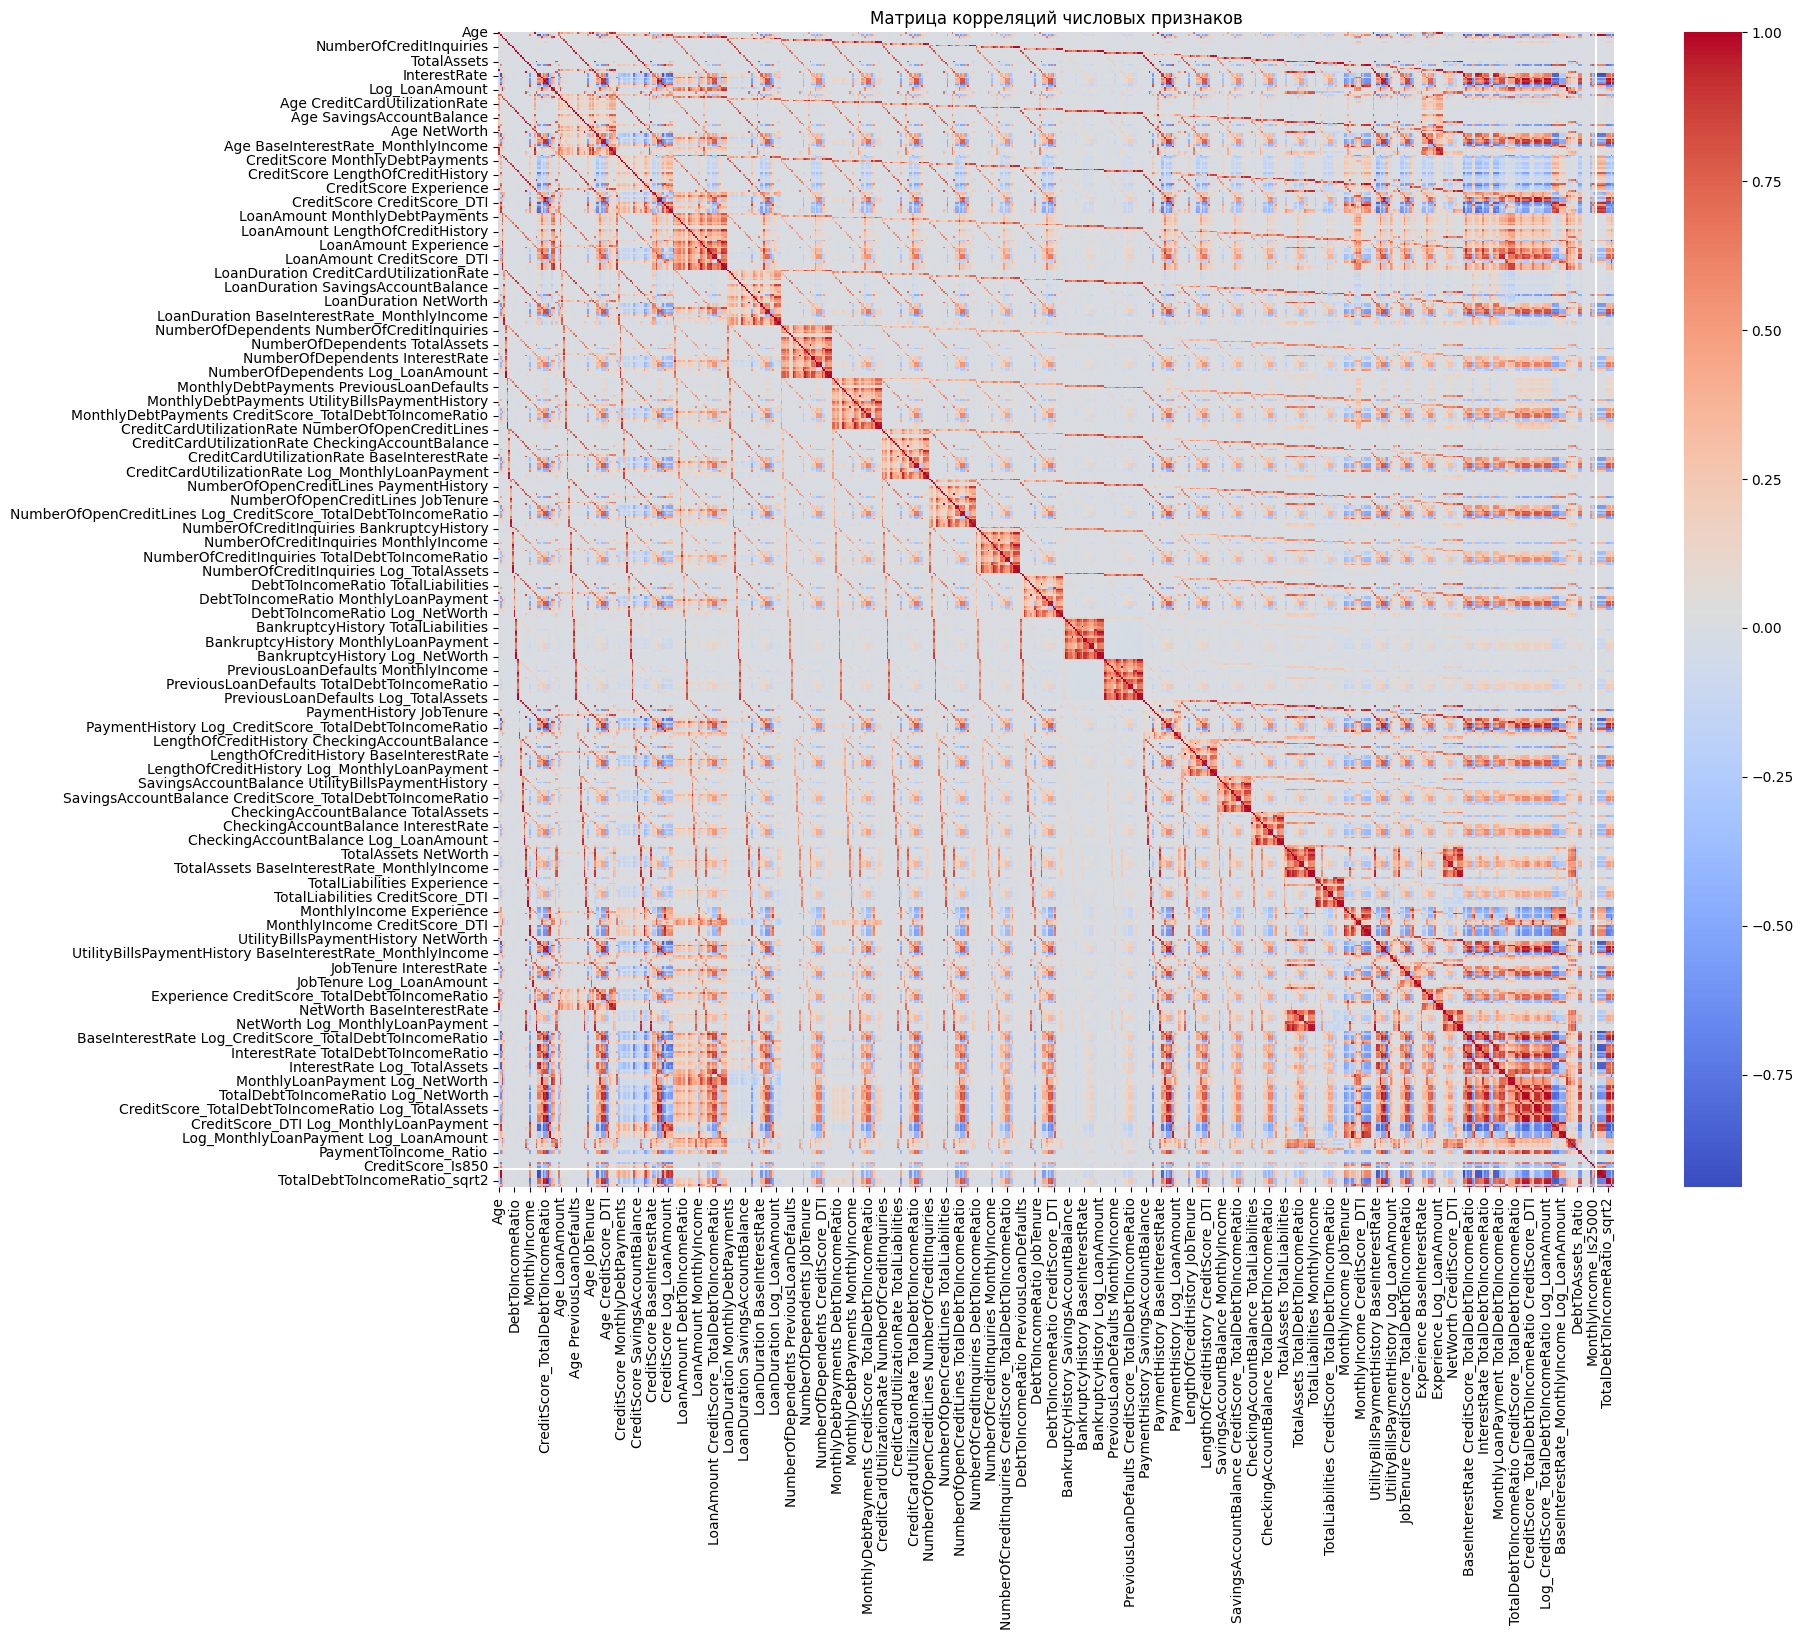

CreditScore_DTI Log_TotalAssets               0.865019
CreditScore_DTI                               0.861711
CreditScore_DTI Log_LoanAmount                0.855914
CreditScore CreditScore_DTI                   0.850878
CreditScore_DTI Log_NetWorth                  0.850236
CreditScore_DTI Log_MonthlyLoanPayment        0.837787
UtilityBillsPaymentHistory CreditScore_DTI    0.804539
TotalDebtToIncomeRatio_sqrt3                  0.794402
CreditScore MonthlyIncome                     0.781124
TotalDebtToIncomeRatio_sqrt2                  0.777121
Name: RiskScore, dtype: float64
NumberOfOpenCreditLines UtilityBillsPaymentHistory    0.003226
NumberOfOpenCreditLines SavingsAccountBalance         0.002410
NumberOfDependents NumberOfOpenCreditLines            0.002397
Age MonthlyDebtPayments                               0.002150
NumberOfOpenCreditLines CheckingAccountBalance        0.002014
PreviousLoanDefaults TotalAssets                      0.001485
TotalLiabilities Experience             

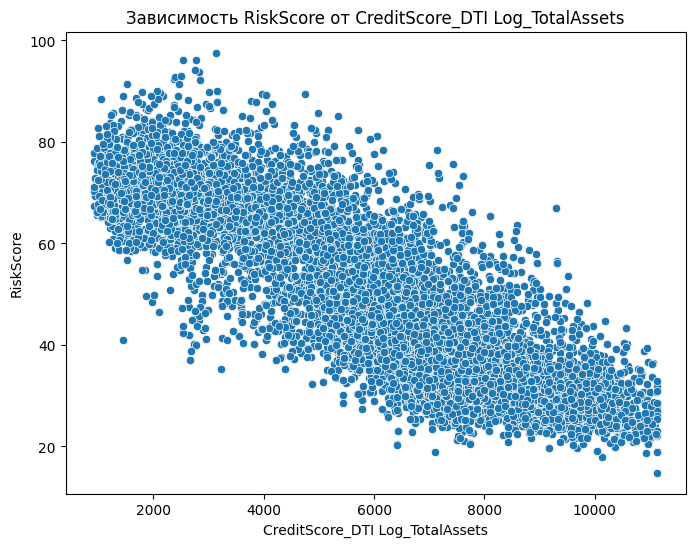

In [20]:
plt.figure(figsize=(18, 15))
corr_mat = X.select_dtypes(include=['number']).corr()
sns.heatmap(corr_mat, cmap='coolwarm')
plt.title('Матрица корреляций числовых признаков')
plt.show()

tmp_df = X.select_dtypes(include=['number']).join(y)

corr_with_target = tmp_df.corr()['RiskScore'].abs().sort_values(ascending=False)

print(corr_with_target.head(11).drop('RiskScore'))
print("=====================")
print(corr_with_target.tail(10))

most_correlated_feature = corr_with_target.index[1]

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X[most_correlated_feature], y=y)
plt.title(f'Зависимость RiskScore от {most_correlated_feature}')
plt.xlabel(most_correlated_feature)
plt.ylabel('RiskScore')
plt.show()

Вывод: как видно из вывода ячейки выше, riskscore очень сильно зависит от CreditScore и его производных, а также связей с другими признаками (MonthlyLoanPayment, MonthlyIncome и др). Повысить точность можно, скорее всего, убрав повторяющиеся (например, там может быть log с log и такое же с sqrt и sqrt -- просто надо делать так, чтобы выбиралось только самое сильное). 

In [22]:
def z_score_scaler_fit(data):
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    std[std == 0] = 1
    return mean, std

def z_score_scaler_transform(data, mean, std):
    return (data - mean) / std

def min_max_scaler_fit(data):
    min_val = np.min(data, axis=0)
    max_val = np.max(data, axis=0)
    scale = max_val - min_val
    scale[scale == 0] = 1
    return min_val, scale

def min_max_scaler_transform(data, min_val, scale):
    return (data - min_val) / scale


X_np = X.astype(float).values
y_np = y.values
X_test_np = X_test.astype(float).values

mean_z, std_z = z_score_scaler_fit(X_np)
X_scaled = z_score_scaler_transform(X_np, mean_z, std_z)
X_test_scaled = z_score_scaler_transform(X_test_np, mean_z, std_z)

min_mm, scale_mm = min_max_scaler_fit(X_np)
X_mm_scaled = min_max_scaler_transform(X_np, min_mm, scale_mm)

In [ ]:
class MyLinearRegression:
    def __init__(self, learning_rate=0.01, iterations=1000, method='analytical', ):
        self.weights = None
        self.method = method
        self.learning_rate = learning_rate
        self.iterations = iterations

    def _add_intercept(self, X):
        intercept = np.ones((X.shape[0], 1))
        return np.c_[intercept, X]

    def fit(self, X, y):
        X_b = self._add_intercept(X)
        n_samples, n_features = X_b.shape

        self.weights = np.zeros(n_features)

        if self.method == 'analytical':
            try:
                self.weights = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y
            except np.linalg.LinAlgError:
                print("Аналитическое решение невозможно. Попробуйте GD/SGD.")

        elif self.method == 'gradient':
            for _ in range(self.iterations):
                predictions = X_b @ self.weights
                errors = predictions - y
                gradients = (2 / n_samples) * X_b.T @ errors
                self.weights -= self.learning_rate * gradients

        elif self.method == 'sgradient':
            for _ in range(self.iterations):
                indices = np.arange(n_samples)
                np.random.shuffle(indices)
                for i in indices:       
                    xi = X_b[i:i+1]
                    yi = y[i:i+1]

                    predictions = xi @ self.weights
                    errors = predictions - yi
                    gradients = 2 * xi.T @ errors
                    self.weights -= self.learning_rate * gradients

        else:
            raise ValueError(f"Неизвестный метод '{self.method}'. Доступные методы: 'analytical', 'gradient', 'sgradient'.")

        return self

    def predict(self, X):
        if self.weights is None:
            raise Exception("Модель не обучена. Сначала вызовите метод fit().")

        X_b = self._add_intercept(X)
        return X_b @ self.weights

In [24]:
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    if ss_tot == 0:
        return 1.0 if ss_res == 0 else 0.0
    return 1 - (ss_res / ss_tot)

def mape(y_true, y_pred):
    y_true_safe = np.where(y_true == 0, 1e-8, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true_safe)) * 100

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression as SklearnLinearRegression
from sklearn.metrics import mean_squared_error as sklearn_mse

X_train, X_val, y_train_split, y_val_split = train_test_split(X_scaled, y_np, test_size=0.2, random_state=42)

my_analytic = MyLinearRegression(method='analytical')
my_analytic.fit(X_train, y_train_split)
pred_analytic = my_analytic.predict(X_val)
mse_analytic = mse(y_val_split, pred_analytic)
print(f"MSE: {mse_analytic:.4f}\n")
print(f"SK MSE {sklearn_mse(y_val_split, pred_analytic)}\n")


my_gradient = MyLinearRegression(method='gradient', learning_rate=0.00009, iterations=2500) # если поставить итераций больше, то будет точнее, но дольше (при 25000 было mse где-то 26.5 , но и думало 18 минут)
my_gradient.fit(X_train, y_train_split)
pred_gd = my_gradient.predict(X_val)
mse_gd = mse(y_val_split, pred_gd)
print(f"MSE grad: {mse_gd:.4f}\n")


my_sgradient = MyLinearRegression(method='sgradient', learning_rate=0.00001, iterations=1000)
my_sgradient.fit(X_train, y_train_split)
pred_sgd = my_sgradient.predict(X_val)
mse_sgd = mse(y_val_split, pred_sgd)
print(f"MSE sgradient: {mse_sgd:.4f}\n")


sklearn_lr = SklearnLinearRegression()
sklearn_lr.fit(X_train, y_train_split)
pred_sklearn = sklearn_lr.predict(X_val)
mse_sklearn = mse(y_val_split, pred_sklearn)
print(f"MSE SklearnLinearRegression: {mse_sklearn:.4f}\n")

MSE: 26.4709

SK MSE 26.47090921713868
MSE: 986.9385

MSE: 26.4080

MSE: 26.4865



In [36]:
from sklearn.linear_model import LinearRegression as SklearnLinearRegression


print(f"MSE: {mse(y_val_split, pred_analytic):.4f}")
print(f"MAPE: {mape(y_val_split, pred_analytic):.4f}")
print(f"MAE: {mae(y_val_split, pred_analytic):.4f}")
print(f"R^2: {r2_score(y_val_split, pred_analytic):.4f}\n")

from sklearn.metrics import mean_squared_error as sklearn_mse
from sklearn.metrics import mean_absolute_error as sklearn_mae
from sklearn.metrics import r2_score as sklearn_r2
from sklearn.metrics import mean_absolute_percentage_error as sklearn_mape


print(f"MSE: {sklearn_mse(y_val_split, pred_sklearn):.4f}")
print(f"MAPE: {sklearn_mape(y_val_split, pred_sklearn)*100:.4f}")
print(f"MAE: {sklearn_mae(y_val_split, pred_sklearn):.4f}")
print(f"R^2: {sklearn_r2(y_val_split, pred_sklearn):.4f}\n")

MSE: 26.4709
MAPE: 8.8333
MAE: 3.7750
R^2: 0.9115

MSE: 26.4865
MAPE: 8.8353
MAE: 3.7764
R^2: 0.9114



## K-Fold

In [37]:
def k_fold_cross_validation(model_class, X, y, k=5, scoring_func=None, 
                           random_state=None, shuffle=True, **model_kwargs):
    if random_state is not None:
        np.random.seed(random_state)
    
    if scoring_func is None:
        scoring_func = lambda y_true, y_pred: np.mean((y_true - y_pred) ** 2)
    
    n_samples = len(X)
    indices = np.arange(n_samples)
    
    if shuffle:
        np.random.shuffle(indices)
    
    fold_sizes = np.full(k, n_samples // k, dtype=int)
    fold_sizes[:n_samples % k] += 1
    
    current = 0
    folds = []
    for fold_size in fold_sizes:
        start, stop = current, current + fold_size
        folds.append(indices[start:stop])
        current = stop
    
    scores = []
    
    for i in range(k):
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        model = model_class(**model_kwargs)
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_val)
        score = scoring_func(y_val, y_pred)
        scores.append(score)
        
        print(f"Fold {i+1}/{k}: score = {score:.6f}")
    
    return np.array(scores)

In [38]:
scores = k_fold_cross_validation(
    model_class=MyLinearRegression,
    X=X_train,
    y=y_train_split,
    k=10,
    random_state=42,
learning_rate=9e-4, n_iterations=25000
)

print(f"Средний MSE по фолдам: {scores.mean():.4f}")
print(f"Стандартное отклонение MSE: {scores.std():.4f}")

from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression as SklearnLinearRegression

print("kfold SK")
sklearn_model = SklearnLinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)
sklearn_scores = -cross_val_score(sklearn_model, X_scaled, y_np, cv=kf, scoring='neg_mean_squared_error')

print(f"Средняя MSE (sklearn): {np.mean(sklearn_scores):.4f}")

Fold 1/10: score = 23.630138
Fold 2/10: score = 24.621538
Fold 3/10: score = 25.448125
Fold 4/10: score = 26.631935
Fold 5/10: score = 29.479112
Fold 6/10: score = 27.425197
Fold 7/10: score = 27.380820
Fold 8/10: score = 25.866459
Fold 9/10: score = 23.172048
Fold 10/10: score = 25.728992
Средний MSE по фолдам: 25.9384
Стандартное отклонение MSE: 1.7976
kfold SK
Средняя MSE (sklearn): 25.9459


## Регуляризация

In [39]:
import numpy as np
import warnings

class MyRegularizedLinearRegression:
    def __init__(self, alpha=0.01, regularization='l2', l1_ratio=0.5, p=2, 
                 learning_rate=0.01, iterations=1000, method='gradient',
                 batch_size=None, shuffle=True, random_state=None, 
                 tol=1e-4, early_stopping=False, verbose=0):
        self.weights = None
        self.alpha = alpha
        self.regularization = regularization.lower()
        self.l1_ratio = l1_ratio
        self.p = p
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.method = method.lower()
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.random_state = random_state
        self.tol = tol
        self.early_stopping = early_stopping
        self.verbose = verbose
        
        if random_state is not None:
            np.random.seed(random_state)
            
        self.loss_history = []
        self._validate_params()
        
    def _validate_params(self):
        valid_methods = ['analytical', 'gradient', 'sgd']
        if self.method not in valid_methods:
            raise ValueError(f"method должен быть один из {valid_methods}")
        
        valid_regularizations = ['l1', 'l2', 'elasticnet', 'lp']
        if self.regularization not in valid_regularizations:
            raise ValueError(f"regularization должен быть один из {valid_regularizations}")
            
        if self.method == 'analytical' and self.regularization != 'l2':
            warnings.warn(f"Аналитическое решение доступно только для L2. Переключаюсь на gradient descent.")
            self.method = 'gradient'
            
        if self.batch_size is not None and self.batch_size < 1:
            raise ValueError("batch_size должен быть >= 1 или None")
            
        if self.alpha < 0:
            raise ValueError("alpha должен быть >= 0")
            
        if self.l1_ratio < 0 or self.l1_ratio > 1:
            raise ValueError("l1_ratio должен быть в диапазоне [0, 1]")
            
        if self.p <= 0:
            raise ValueError("p должен быть > 0")
            
        if self.learning_rate <= 0:
            raise ValueError("learning_rate должен быть > 0")

    def _add_intercept(self, X):
        intercept = np.ones((X.shape[0], 1))
        return np.hstack([intercept, X])

    def _compute_loss(self, X_b, y, weights):
        predictions = X_b @ weights
        errors = predictions - y
        mse = np.mean(errors ** 2)
        
        w_no_intercept = weights[1:]
        
        if self.regularization == 'l2':
            penalty = self.alpha * np.sum(w_no_intercept ** 2)
        elif self.regularization == 'l1':
            penalty = self.alpha * np.sum(np.abs(w_no_intercept))
        elif self.regularization == 'elasticnet':
            l1_penalty = np.sum(np.abs(w_no_intercept))
            l2_penalty = np.sum(w_no_intercept ** 2)
            penalty = self.alpha * (self.l1_ratio * l1_penalty + (1 - self.l1_ratio) * l2_penalty)
        elif self.regularization == 'lp':
            penalty = self.alpha * np.sum(np.abs(w_no_intercept) ** self.p)
        else:
            penalty = 0
            
        return mse + penalty

    def _compute_gradient(self, X_batch, y_batch, weights):
        n_batch = len(y_batch)
        predictions = X_batch @ weights
        errors = predictions - y_batch
        
        grad_mse = (2 / n_batch) * X_batch.T @ errors
        
        grad_penalty = np.zeros_like(weights)
        w_no_intercept = weights[1:]
        
        if self.regularization == 'l2':
            grad_penalty[1:] = 2 * self.alpha * w_no_intercept
        elif self.regularization == 'l1':
            grad_penalty[1:] = self.alpha * np.sign(w_no_intercept)
        elif self.regularization == 'elasticnet':
            grad_penalty[1:] = self.alpha * (
                self.l1_ratio * np.sign(w_no_intercept) + 
                2 * (1 - self.l1_ratio) * w_no_intercept
            )
        elif self.regularization == 'lp':
            if self.p == 1:
                grad_penalty[1:] = self.alpha * np.sign(w_no_intercept)
            else:
                grad_penalty[1:] = self.alpha * self.p * np.abs(w_no_intercept) ** (self.p - 1) * np.sign(w_no_intercept)
        
        return grad_mse + grad_penalty

    def _sgd_step(self, X_b, y, weights, iteration):
        n_samples = len(y)
        
        if self.batch_size is None:
            batch_size = 1
        else:
            batch_size = min(self.batch_size, n_samples)
        
        indices = np.arange(n_samples)
        if self.shuffle:
            np.random.shuffle(indices)
        
        for start_idx in range(0, n_samples, batch_size):
            end_idx = min(start_idx + batch_size, n_samples)
            batch_idx = indices[start_idx:end_idx]
            
            X_batch = X_b[batch_idx]
            y_batch = y[batch_idx]
            
            gradient = self._compute_gradient(X_batch, y_batch, weights)
            weights -= self.learning_rate * gradient
        
        return weights

    def fit(self, X, y):
        X_b = self._add_intercept(X)
        n_samples, n_features = X_b.shape
        
        if self.weights is None:
            self.weights = np.random.randn(n_features) * 0.01
        
        # Аналитическое решение (только для L2)
        if self.method == 'analytical':
            if self.regularization != 'l2':
                raise ValueError("Аналитическое решение доступно только для L2 регуляризации")
            
            # Ridge регрессия: (X.T @ X + alpha*I) @ w = X.T @ y
            identity = np.eye(n_features)
            identity[0, 0] = 0
            
            try:
                A = X_b.T @ X_b + 2 * self.alpha * identity
                b = X_b.T @ y
                self.weights = np.linalg.solve(A, b)
                
                loss = self._compute_loss(X_b, y, self.weights)
                self.loss_history.append(loss)
                
                if self.verbose > 0:
                    print(f"Analytical solution found. Loss: {loss:.6f}")
                    
            except np.linalg.LinAlgError:
                warnings.warn("Матрица вырождена. Использую gradient descent вместо аналитического решения.")
                self.method = 'gradient'
        
        if self.method == 'gradient':
            if self.verbose > 0:
                pass
            
            for iteration in range(self.iterations):
                gradient = self._compute_gradient(X_b, y, self.weights)
                
                self.weights -= self.learning_rate * gradient
                
                loss = self._compute_loss(X_b, y, self.weights)
                self.loss_history.append(loss)
                
                if self.early_stopping and iteration > 0:
                    loss_change = abs(self.loss_history[-2] - loss)
                    if loss_change < self.tol:
                        break
        
        # Стохастический градиентный спуск
        elif self.method == 'sgd':
            initial_lr = self.learning_rate
            
            for epoch in range(self.iterations):
                if epoch > 0:
                    self.learning_rate = initial_lr / (1 + 0.01 * epoch)
                
                self.weights = self._sgd_step(X_b, y, self.weights, epoch)
                
                loss = self._compute_loss(X_b, y, self.weights)
                self.loss_history.append(loss)
                
                if self.early_stopping and epoch > 10:
                    if len(self.loss_history) > 10:
                        recent_losses = self.loss_history[-10:]
                        loss_std = np.std(recent_losses)
                        if loss_std < self.tol:
                            break

        self.learning_rate = initial_lr if 'initial_lr' in locals() else self.learning_rate
        
        return self

    def predict(self, X):
        if self.weights is None:
            raise Exception("Модель не обучена. Сначала вызовите метод fit().")
        X_b = self._add_intercept(X)
        return X_b @ self.weights

    def get_coefficients(self):
        if self.weights is None:
            raise Exception("Модель не обучена.")
        return self.weights[1:]

    def get_intercept(self):
        if self.weights is None:
            raise Exception("Модель не обучена.")
        return self.weights[0]

    def score(self, X, y):
        if self.weights is None:
            raise Exception("Модель не обучена.")
        
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        
        return 1 - (ss_res / ss_tot)

    def get_loss_history(self):
        return self.loss_history

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train_split, y_val_split = train_test_split(X_scaled, y_np, test_size=0.2, random_state=42)

reg_analytic = MyRegularizedLinearRegression(
    alpha=0.1,
    regularization='elasticnet',
    l1_ratio=0.75,
    method='gradient',
    iterations=25000,
    learning_rate=9e-4,
    early_stopping=True,
    tol=1e-6,
    verbose=1
)
reg_analytic.fit(X_train, y_train_split)
predictions_analytic = reg_analytic.predict(X_val)
mse_analytic = mse(y_val_split, predictions_analytic)
print(f"MSE: {mse_analytic:.4f}\n")

MSE: 28.0010



# LOO (eave-one-out)

In [ ]:
def leave_one_out_cross_validation(model, X, y, scoring_func=mse):
    n_samples = X.shape[0]
    return k_fold_cross_validation(model, X, y, k=n_samples, scoring_func=scoring_func, random_state=None)

X_subset = X_scaled[:100]
y_subset = y_np[:100]

my_model_for_loocv = MyLinearRegression(method='analytical')
loocv_scores = leave_one_out_cross_validation(my_model_for_loocv, X_subset, y_subset)

print(f"Средняя MSE: {np.mean(loocv_scores):.4f}")
print(f"Стандартное отклонение: {np.std(loocv_scores):.4f}\n")

--- Тестирование Leave-One-Out на небольшом подмножестве (100 объектов) ---
Запуск 100-Fold кросс-валидации...
  Фолд 1/100, Метрика (mse): 584.8540
  Фолд 2/100, Метрика (mse): 764.2661
  Фолд 3/100, Метрика (mse): 2487.1322
  Фолд 4/100, Метрика (mse): 299.2899
  Фолд 5/100, Метрика (mse): 1377.2849
  Фолд 6/100, Метрика (mse): 1.0503
  Фолд 7/100, Метрика (mse): 699.8730
  Фолд 8/100, Метрика (mse): 1361.8197
  Фолд 9/100, Метрика (mse): 66745.7400
  Фолд 10/100, Метрика (mse): 812.7261
  Фолд 11/100, Метрика (mse): 101.5917
  Фолд 12/100, Метрика (mse): 223.6707
  Фолд 13/100, Метрика (mse): 108.5410
  Фолд 14/100, Метрика (mse): 1.6375
  Фолд 15/100, Метрика (mse): 6511.3758
  Фолд 16/100, Метрика (mse): 152.6503
  Фолд 17/100, Метрика (mse): 2587.6488
  Фолд 18/100, Метрика (mse): 109.2816
  Фолд 19/100, Метрика (mse): 3672.9687
  Фолд 20/100, Метрика (mse): 46.3825
  Фолд 21/100, Метрика (mse): 35.0304
  Фолд 22/100, Метрика (mse): 913.0928
  Фолд 23/100, Метрика (mse): 57.0826


## Сохраниние в файлик отправки

In [ ]:
final_model = MyLinearRegression(method='analytical', learning_rate=1e-6, iterations=10000)
final_model.fit(X_scaled, y_np)

final_predictions = final_model.predict(X_test_scaled)

submission_df = pd.DataFrame({
    'ID': test_ids,
    'RiskScore': final_predictions
})
submission_df.to_csv('submission.csv', index=False)

print(submission_df.head())

   ID  RiskScore
0   0  34.013026
1   1  53.196287
2   2  29.134883
3   3  36.215262
4   4  36.323184
